# SuGaR: Surface-Aligned Gaussian Splatting — Google Colab Pipeline (DTU)

This notebook runs the full **SuGaR** pipeline on Google Colab using the **DTU** dataset,
and evaluates both novel view synthesis quality and geometry reconstruction quality.

**Before running:**
- Select **Runtime → Change runtime type → GPU** (T4 or better recommended)
- Upload the required data to Google Drive (see cell 2 for exact paths)

**Required data on Drive:**
```
MyDrive/3dgs_data/dtu/scan24/
  images/          ← PNG images from 2DGS-preprocessed DTU
  cameras.npz      ← camera matrices (NeuS/IDR format)
  mask/            ← binary mask images for Chamfer evaluation culling

MyDrive/3dgs_data/dtu_gt/
  ObsMask/
    ObsMask24_10.mat
    Plane24.mat
  Points/
    stl/
      stl024_total.ply
```

**Data downloads:**
- Preprocessed DTU (pick scan24/): https://drive.google.com/drive/folders/1SJFgt8qhQomHX55Q4xSvYE2C6-8tFll9
- Official DTU GT point clouds: https://roboimagedata.compute.dtu.dk/?page_id=36 (download SampleSet)

**Pipeline steps:**
1. Convert DTU camera format (cameras.npz → COLMAP text) so SuGaR can read it
2. Reconstruct sparse point cloud via COLMAP triangulation (~15–20 min, one-time)
3. Vanilla 3DGS optimization (7k iterations)
4. SuGaR coarse optimization with density regularization
5. Mesh extraction via Poisson reconstruction
6. SuGaR refinement (Gaussians bound to mesh)
7. Textured mesh export (.obj) and Gaussian export (.ply)
8. Novel view synthesis evaluation: PSNR / SSIM / LPIPS
9. Geometry evaluation: Chamfer distance vs DTU GT point clouds

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configure Paths

Edit the variables below to match your Drive directory layout.

In [ ]:
import os

# ── User-configurable ─────────────────────────────────────────────────────────
# DTU scan to train and evaluate on.
# scan24 (a rock) is the most commonly used benchmark scan.
DTU_SCAN_ID = 24

# Path to the 2DGS-preprocessed DTU scan on Drive.
# Expected contents: images/, cameras.npz, mask/
# Download from: https://drive.google.com/drive/folders/1SJFgt8qhQomHX55Q4xSvYE2C6-8tFll9
SCENE_PATH = f'/content/drive/MyDrive/3dgs_data/dtu/scan{DTU_SCAN_ID}'

# Path to the official DTU GT evaluation data on Drive.
# Expected structure: ObsMask/ObsMask{N}_10.mat, ObsMask/Plane{N}.mat,
#                     Points/stl/stl{N:03d}_total.ply
# Download SampleSet from: https://roboimagedata.compute.dtu.dk/?page_id=36
DTU_GT_PATH = '/content/drive/MyDrive/3dgs_data/dtu_gt'

# Where final outputs (meshes, Gaussians, etc.) will be saved on Drive
OUTPUT_DIR_DRIVE = '/content/drive/MyDrive/3dgs/SuGaR_output'

# Regularization type: 'dn_consistency' (recommended), 'density', or 'sdf'
REGULARIZATION = 'density'

# Mesh quality: 'high_poly' (1M vertices, 1 gaussian/triangle)
#               'low_poly'  (200k vertices, 6 gaussians/triangle)
MESH_QUALITY = 'high_poly'

# Refinement time: 'short' (2k iters), 'medium' (7k iters), 'long' (15k iters)
REFINEMENT_TIME = 'medium'

# Export a UV-textured .obj mesh
EXPORT_OBJ = True

# Export a .ply file of the refined Gaussians (viewable in SuperSplat / viewers)
EXPORT_PLY = True

# GPU index (0 for the single Colab GPU)
GPU_INDEX = 0
# ─────────────────────────────────────────────────────────────────────────────

# Derived paths (do not change)
SUGAR_DIR      = '/content/SuGaR'
OUTPUT_SYMLINK = os.path.join(SUGAR_DIR, 'output')
SCENE_NAME     = f'scan{DTU_SCAN_ID}'

# Validate scene path and required DTU files
assert os.path.isdir(SCENE_PATH), (
    f"Scene directory not found: {SCENE_PATH}\n"
    "Upload the 2DGS-preprocessed DTU scan to Google Drive and update SCENE_PATH."
)
cameras_npz = os.path.join(SCENE_PATH, 'cameras.npz')
images_dir  = os.path.join(SCENE_PATH, 'images')
mask_dir    = os.path.join(SCENE_PATH, 'mask')
for p in [cameras_npz, images_dir, mask_dir]:
    assert os.path.exists(p), f"Expected path missing: {p}"

print(f"Scene:       {SCENE_NAME}  ({len(os.listdir(images_dir))} images)")
print(f"cameras.npz: found")
print(f"mask/:       found  ({len(os.listdir(mask_dir))} files)")
print(f"DTU GT path: {DTU_GT_PATH}")

## 2a. Convert DTU Cameras to COLMAP Format

DTU data uses the NeuS/IDR camera format (`cameras.npz` with full projection matrices).
SuGaR training expects COLMAP format (`sparse/0/cameras.txt` + `images.txt`).

This cell derives COLMAP cameras from `P = world_mat @ scale_mat`, placing SuGaR's
training in the same normalized coordinate space that the Chamfer evaluation uses.

**Run this cell once per scan.** It is safe to re-run.

In [ ]:
import glob
import numpy as np
import cv2
from PIL import Image as _PILImage

cameras_npz = os.path.join(SCENE_PATH, 'cameras.npz')
images_dir  = os.path.join(SCENE_PATH, 'images')
sparse_dir  = os.path.join(SCENE_PATH, 'sparse', '0')
os.makedirs(sparse_dir, exist_ok=True)

camera_dict = np.load(cameras_npz)
image_files = sorted(glob.glob(os.path.join(images_dir, '*.png')))
n_images    = len(image_files)
print(f"Found {n_images} images")

# ── Decompose each P = world_mat @ scale_mat into intrinsics + c2w pose ───────
# Using P = world_mat @ scale_mat ensures training and Chamfer evaluation share
# the same coordinate space (the scale_mat-normalized DTU world).
intrinsics_all = []
poses_all      = []   # camera-to-world (c2w) 4×4 matrices

for i in range(n_images):
    world_mat = camera_dict[f'world_mat_{i}'].astype(np.float64)
    scale_mat = camera_dict[f'scale_mat_{i}'].astype(np.float64)
    P = (world_mat @ scale_mat)[:3, :4]

    # cv2 decomposes P = K [R | t] and returns:
    #   K:   intrinsic matrix
    #   R:   world-to-camera rotation
    #   t_h: camera centre in homogeneous world coordinates
    out   = cv2.decomposeProjectionMatrix(P)
    K     = out[0]; K /= K[2, 2]
    R_w2c = out[1]
    t_h   = out[2]
    cam_center = (t_h[:3] / t_h[3]).reshape(3)

    c2w = np.eye(4)
    c2w[:3, :3] = R_w2c.T        # camera-to-world rotation
    c2w[:3,  3] = cam_center     # camera position in world
    intrinsics_all.append(K)
    poses_all.append(c2w)

# Determine image resolution from first image
W, H = _PILImage.open(image_files[0]).size

# All DTU images share the same intrinsics — use camera 0
K0 = intrinsics_all[0]
fx, fy = float(K0[0, 0]), float(K0[1, 1])
cx, cy = float(K0[0, 2]), float(K0[1, 2])

# ── Write cameras.txt ─────────────────────────────────────────────────────────
cameras_txt = os.path.join(sparse_dir, 'cameras.txt')
with open(cameras_txt, 'w') as f:
    f.write("# Camera list with one line of data per camera:\n")
    f.write("#   CAMERA_ID, MODEL, WIDTH, HEIGHT, PARAMS[]\n")
    f.write(f"1 PINHOLE {W} {H} {fx:.10f} {fy:.10f} {cx:.10f} {cy:.10f}\n")
print(f"Wrote cameras.txt  (PINHOLE {W}×{H}, fx={fx:.1f}, fy={fy:.1f})")

# ── Write images.txt ──────────────────────────────────────────────────────────
def rotmat2qvec(R):
    """Shepperd's method — converts 3×3 rotation matrix to (qw, qx, qy, qz)."""
    Rxx, Ryx, Rzx, Rxy, Ryy, Rzy, Rxz, Ryz, Rzz = R.flat
    K = np.array([
        [Rxx - Ryy - Rzz, 0, 0, 0],
        [Ryx + Rxy, Ryy - Rxx - Rzz, 0, 0],
        [Rzx + Rxz, Rzy + Ryz, Rzz - Rxx - Ryy, 0],
        [Ryz - Rzy, Rzx - Rxz, Rxy - Ryx, Rxx + Ryy + Rzz]]) / 3.0
    eigvals, eigvecs = np.linalg.eigh(K)
    q = eigvecs[[3, 0, 1, 2], np.argmax(eigvals)]
    if q[0] < 0:
        q *= -1
    return q

images_txt = os.path.join(sparse_dir, 'images.txt')
with open(images_txt, 'w') as f:
    f.write("# Image list with two lines of data per image:\n")
    f.write("#   IMAGE_ID, QW, QX, QY, QZ, TX, TY, TZ, CAMERA_ID, NAME\n")
    f.write("#   POINTS2D[] as (X, Y, POINT3D_ID)\n")
    for i, (c2w, img_path) in enumerate(zip(poses_all, image_files)):
        img_name = os.path.basename(img_path)
        R_w2c = c2w[:3, :3].T
        t_w2c = -R_w2c @ c2w[:3, 3]
        qvec  = rotmat2qvec(R_w2c)   # (qw, qx, qy, qz)
        f.write(
            f"{i+1} "
            f"{qvec[0]:.10f} {qvec[1]:.10f} {qvec[2]:.10f} {qvec[3]:.10f} "
            f"{t_w2c[0]:.10f} {t_w2c[1]:.10f} {t_w2c[2]:.10f} "
            f"1 {img_name}\n"
        )
        f.write("\n")   # empty POINTS2D line
print(f"Wrote images.txt  ({n_images} cameras)")

# ── Write placeholder points3D.txt (populated by COLMAP triangulation below) ──
points_txt = os.path.join(sparse_dir, 'points3D.txt')
with open(points_txt, 'w') as f:
    f.write("# 3D point list — populated by COLMAP point_triangulator\n")
print(f"Wrote points3D.txt  (empty placeholder — run triangulation cell next)")
print(f"\nCOLMAP text model ready in: {sparse_dir}")

## 2b. Reconstruct Sparse Point Cloud (COLMAP Triangulation)

Uses COLMAP to triangulate 3D feature points from the known camera poses written above.
This gives SuGaR's 3DGS a proper initial point cloud for optimization.

**Steps:** feature extraction → exhaustive matching → point triangulation

**Expected runtime:** ~15–20 minutes (one-time per scan).

> If `sparse/0/points3D.bin` already exists with points, this cell skips automatically.

In [ ]:
import os, glob, struct

sparse_dir = os.path.join(SCENE_PATH, 'sparse', '0')
images_dir = os.path.join(SCENE_PATH, 'images')
db_path    = os.path.join(SCENE_PATH, 'colmap.db')

# ── Skip if triangulation already completed ────────────────────────────────────
pts_bin = os.path.join(sparse_dir, 'points3D.bin')
if os.path.isfile(pts_bin) and os.path.getsize(pts_bin) > 8:
    with open(pts_bin, 'rb') as _f:
        n_pts = struct.unpack('<Q', _f.read(8))[0]
    if n_pts > 0:
        print(f"points3D.bin already contains {n_pts} points — skipping triangulation.")
        print(f"  Files in sparse/0/: {os.listdir(sparse_dir)}")
        raise SystemExit(0)

# ── Install COLMAP ─────────────────────────────────────────────────────────────
!apt-get install -y -qq colmap

# Read intrinsics written by the conversion cell above
with open(os.path.join(sparse_dir, 'cameras.txt')) as _f:
    for _line in _f:
        if _line.startswith('#') or not _line.strip():
            continue
        _parts = _line.split()
        # PINHOLE: CAMERA_ID MODEL W H fx fy cx cy
        _fx, _fy, _cx, _cy = _parts[4], _parts[5], _parts[6], _parts[7]
        break
camera_params = f"{_fx},{_fy},{_cx},{_cy}"
print(f"Intrinsics: fx={_fx}  fy={_fy}  cx={_cx}  cy={_cy}")

# ── 1. Feature extraction with known intrinsics ────────────────────────────────
# single_camera=1: all images share one camera model (true for DTU)
print("\nStep 1/3: Feature extraction …")
!colmap feature_extractor \
    --database_path "{db_path}" \
    --image_path "{images_dir}" \
    --ImageReader.single_camera 1 \
    --ImageReader.camera_model PINHOLE \
    --ImageReader.camera_params "{camera_params}" \
    --SiftExtraction.use_gpu 1

# ── 2. Exhaustive feature matching ─────────────────────────────────────────────
print("\nStep 2/3: Feature matching …")
!colmap exhaustive_matcher \
    --database_path "{db_path}" \
    --SiftMatching.use_gpu 1

# ── 3. Point triangulation using known camera poses ────────────────────────────
# point_triangulator reads cameras.txt / images.txt (our known poses) and the
# feature matches from the database, then writes cameras.bin / images.bin /
# points3D.bin to the same folder.  SuGaR prefers binary and will pick it up.
print("\nStep 3/3: Point triangulation …")
!colmap point_triangulator \
    --database_path "{db_path}" \
    --image_path "{images_dir}" \
    --input_path "{sparse_dir}" \
    --output_path "{sparse_dir}" \
    --Mapper.ba_refine_focal_length 0 \
    --Mapper.ba_refine_principal_point 0 \
    --Mapper.ba_refine_extra_params 0

# ── Verify ─────────────────────────────────────────────────────────────────────
print(f"\nFiles in sparse/0/: {os.listdir(sparse_dir)}")
pts_bin = os.path.join(sparse_dir, 'points3D.bin')
if os.path.isfile(pts_bin):
    with open(pts_bin, 'rb') as _f:
        n_pts = struct.unpack('<Q', _f.read(8))[0]
    print(f"Triangulated {n_pts} 3D points.")
    if n_pts == 0:
        print("WARNING: 0 points triangulated — feature matching may have failed.")
        print("Check the output above for errors.")
else:
    print("WARNING: points3D.bin not found — triangulation likely failed.")

## 3. Install System Dependencies

In [3]:
# libGL and other system libraries needed by Open3D / PyTorch3D
!apt-get update -qq
!apt-get install -y -qq libgl1-mesa-glx libglib2.0-0 libgomp1

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


## 3. Check GPU & Install Dependencies

In [4]:
# Colab already pre-installs a CUDA-compatible PyTorch — verify it works
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
print(f"GPU:             {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected. Go to Runtime > Change runtime type and select a GPU.")

PyTorch version: 2.10.0+cu128
CUDA available:  True
GPU:             NVIDIA A100-SXM4-40GB


In [5]:
!pip install fvcore iopath

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=0a0a325c1624b6623cacfb70d8b902e4525ceea0ce4fbffeaf1da2a92d989b84
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=53d00e84f4fa143bf321d22b0982feacca648ef1c089e15b4c3528c8d86a2364
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [6]:
# Install remaining SuGaR dependencies
!pip install -q plotly rich "plyfile==0.8.1" open3d PyMCubes lpips tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 339.4/339.4 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 154.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 93.9 MB/s eta 0:00:00


In [7]:
import os, glob

!pip install -q fvcore iopath

# PyTorch3D has no prebuilt wheel for Python 3.12+ and is not on PyPI.
# It must be built from the GitHub source the first time (~20 min).
# The resulting wheel is cached to Drive so every subsequent session installs in seconds.
WHEEL_CACHE = '/content/drive/MyDrive/wheels'
os.makedirs(WHEEL_CACHE, exist_ok=True)

existing = glob.glob(os.path.join(WHEEL_CACHE, 'pytorch3d*.whl'))
if existing:
    print(f"Installing pytorch3d from cached wheel: {existing[0]}")
    !pip install "{existing[0]}"
else:
    print("Building pytorch3d from source — one-time ~20 min, then cached to Drive forever...")
    !pip wheel "git+https://github.com/facebookresearch/pytorch3d.git@v0.7.9" -w "{WHEEL_CACHE}"
    wheel = glob.glob(os.path.join(WHEEL_CACHE, 'pytorch3d*.whl'))
    if not wheel:
        raise RuntimeError("pytorch3d wheel build failed — check the output above for errors.")
    !pip install "{wheel[0]}"
    print(f"Done — wheel saved to {wheel[0]}. Next run will be instant.")

Installing pytorch3d from cached wheel: /content/drive/MyDrive/wheels/pytorch3d-0.7.9-cp312-cp312-linux_x86_64.whl
Processing ./drive/MyDrive/wheels/pytorch3d-0.7.9-cp312-cp312-linux_x86_64.whl


## 5. Clone SuGaR Repository

In [8]:
import os

if not os.path.isdir('/content/SuGaR'):
    !git clone https://github.com/destinnsy/SuGaR.git
else:
    print("SuGaR already cloned, skipping.")
    # Ensure submodules are initialised
    !cd /content/SuGaR && git submodule update --init --recursive

print("Repository ready at /content/SuGaR")

Cloning into 'SuGaR'...
remote: Enumerating objects: 2512, done.
remote: Counting objects: 100% (250/250), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 2512 (delta 122), reused 124 (delta 117), pack-reused 2262 (from 1)
Receiving objects: 100% (2512/2512), 98.11 MiB | 20.10 MiB/s, done.
Resolving deltas: 100% (1216/1216), done.
Repository ready at /content/SuGaR


## 6. Build Gaussian Splatting Submodules

Compiles the CUDA extensions for 3DGS rasterization and the KNN search.

In [9]:
# Build diff-gaussian-rasterization
!cd /content/SuGaR/gaussian_splatting/submodules/diff-gaussian-rasterization && \
    pip install -e .

# Build simple-knn
!cd /content/SuGaR/gaussian_splatting/submodules/simple-knn && \
    pip install -e .

print("Gaussian Splatting submodules built successfully.")

Obtaining file:///content/SuGaR/gaussian_splatting/submodules/diff-gaussian-rasterization
  Preparing metadata (setup.py) ... done
  Running setup.py develop for diff_gaussian_rasterization
Obtaining file:///content/SuGaR/gaussian_splatting/submodules/simple-knn
  Preparing metadata (setup.py) ... done
  Running setup.py develop for simple_knn
Gaussian Splatting submodules built successfully.


## 7. Install Nvdiffrast (Optional but Recommended)

Speeds up textured mesh extraction from minutes to seconds.

In [10]:
# !cd /content/SuGaR && git clone https://github.com/NVlabs/nvdiffrast

In [11]:
# !cd /content/SuGaR/nvdiffrast && pip install . --no-build-isolation flag

## 8. Set Up Output Directory

Creates the output folder on Google Drive and symlinks it into the SuGaR working directory
so outputs are saved directly to Drive (survive Colab disconnects).

In [12]:
import os

# Create output folder on Drive
os.makedirs(OUTPUT_DIR_DRIVE, exist_ok=True)

# Remove any existing output dir/symlink inside SuGaR, then symlink to Drive
if os.path.islink(OUTPUT_SYMLINK):
    os.unlink(OUTPUT_SYMLINK)
elif os.path.isdir(OUTPUT_SYMLINK):
    import shutil
    shutil.rmtree(OUTPUT_SYMLINK)

os.symlink(OUTPUT_DIR_DRIVE, OUTPUT_SYMLINK)

print(f"Output symlink created:")
print(f"  {OUTPUT_SYMLINK} → {OUTPUT_DIR_DRIVE}")

Output symlink created:
  /content/SuGaR/output → /content/drive/MyDrive/3dgs/SuGaR_output


## 9. Run the Full SuGaR Pipeline

This is the main training step. Expected runtimes on a T4 GPU:
- Vanilla 3DGS (7k iters): ~10–15 min
- SuGaR coarse optimisation: ~10–20 min
- Mesh extraction: ~5 min
- Refinement (`medium`, 7k iters): ~10–20 min
- Textured mesh export: ~1 min

**Total: ~45–75 minutes**

> ⚠️ Keep the browser tab active or check back periodically. Colab may disconnect after 90 minutes of inactivity on the free tier.

In [ ]:
%cd /content/SuGaR
!python train_full_pipeline.py \
    -s "{SCENE_PATH}" \
    -r {REGULARIZATION} \
    --{MESH_QUALITY} True \
    --refinement_time {REFINEMENT_TIME} \
    --export_obj {EXPORT_OBJ} \
    --export_ply {EXPORT_PLY} \
    --eval True \
    --gs_output_dir "{OUTPUT_SYMLINK}/vanilla_gs/{SCENE_NAME}"

## 10. Verify Outputs

Lists the files saved to your Google Drive output folder.

In [19]:
import os

print(f"Output directory: {OUTPUT_DIR_DRIVE}\n")

for root, dirs, files in os.walk(OUTPUT_DIR_DRIVE):
    # Skip hidden folders
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    level = root.replace(OUTPUT_DIR_DRIVE, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    sub_indent = '  ' * (level + 1)
    for f in files:
        fpath = os.path.join(root, f)
        size_mb = os.path.getsize(fpath) / (1024 ** 2)
        print(f"{sub_indent}{f}  ({size_mb:.1f} MB)")

Output directory: /content/drive/MyDrive/3dgs/SuGaR_output

SuGaR_output/
  vanilla_gs/
    bicycle/
      cfg_args  (0.0 MB)
      input.ply  (1.4 MB)
      cameras.json  (0.1 MB)
      events.out.tfevents.1774744806.75208f12c290.4576.0  (25.3 MB)
      point_cloud/
        iteration_7000/
          point_cloud.ply  (760.2 MB)
  coarse/
    bicycle/
      sugarcoarse_3Dgs7000_densityestim02_sdfnorm02/
        15000.pt  (511.4 MB)
  coarse_mesh/
    bicycle/
      sugarmesh_3Dgs7000_densityestim02_sdfnorm02_level03_decim200000.ply  (15.7 MB)
  refined/
    bicycle/
      sugarfine_3Dgs7000_densityestim02_sdfnorm02_level03_decim200000_normalconsistency01_gaussperface6/
        7000.pt  (1398.1 MB)
  refined_ply/
    bicycle/
      sugarfine_3Dgs7000_densityestim02_sdfnorm02_level03_decim200000_normalconsistency01_gaussperface6.ply  (540.4 MB)
  refined_mesh/
    bicycle/
      sugarfine_3Dgs7000_densityestim02_sdfnorm02_level03_decim200000_normalconsistency01_gaussperface6.obj  (45.1 MB

## Notes on Output Files

After a successful run you should find the following inside `SuGaR_output/`:

| Folder | Contents |
|---|---|
| `vanilla_gs/<scene>/` | Vanilla 3DGS checkpoint (7k iters) |
| `coarse/<scene>/` | Coarse SuGaR model checkpoint |
| `coarse_mesh/<scene>/` | Coarse extracted mesh (`.ply`) |
| `refined/<scene>/` | Refined SuGaR model checkpoint |
| `refined_mesh/<scene>/` | Final mesh (`.obj` + `.mtl` + texture image) |
| `refined_ply/<scene>/` | Refined Gaussians (`.ply`) — open with SuperSplat or any 3DGS viewer |

**To view the Gaussian Splat:**
Download the `.ply` from `refined_ply/` and open it in the [SuperSplat viewer](https://playcanvas.com/supersplat/editor).

**To view the mesh:**
Download the `.obj` from `refined_mesh/` and open it in Blender or MeshLab.

## 11. Visualize Gaussian Distribution (Blue Dot Projection)

Runs `teaser.py` to project Gaussian centers onto the rendered image as blue dots,
letting you see their spatial distribution.

Two modes:
- **Vanilla 3DGS gaussians** (fast check): uses the 7k-iteration checkpoint automatically
- **SuGaR refined gaussians** (recommended): uncomment the `PLY_PATH` line and point it at the exported `.ply`

In [16]:
!git pull

Already up to date.


Using SuGaR refined .ply: /content/SuGaR/output/refined_ply/bicycle/sugarfine_3Dgs7000_densityestim02_sdfnorm02_level03_decim200000_normalconsistency01_gaussperface6.ply
/content/SuGaR
Looking for config file in /content/SuGaR/output/vanilla_gs/bicycle/cfg_args
Config file found: /content/SuGaR/output/vanilla_gs/bicycle/cfg_args
Rendering /content/SuGaR/output/vanilla_gs/bicycle
Rendering source_path /content/drive/MyDrive/3dgs_data/bicycle
Loading trained model at iteration 7000 [29/03 03:51:31]
Reading camera 194/194 [29/03 03:51:32]
Loading Training Cameras [29/03 03:51:32]
[ INFO ] Encountered quite large input images (>1.6K pixels width), rescaling to 1.6K.
 If this is not desired, please explicitly specify '--resolution/-r' as 1 [29/03 03:51:32]
Loading Test Cameras [29/03 03:52:44]
Loading gaussians from: /content/SuGaR/output/refined_ply/bicycle/sugarfine_3Dgs7000_densityestim02_sdfnorm02_level03_decim200000_normalconsistency01_gaussperface6.ply [29/03 03:52:49]
Error: no "view

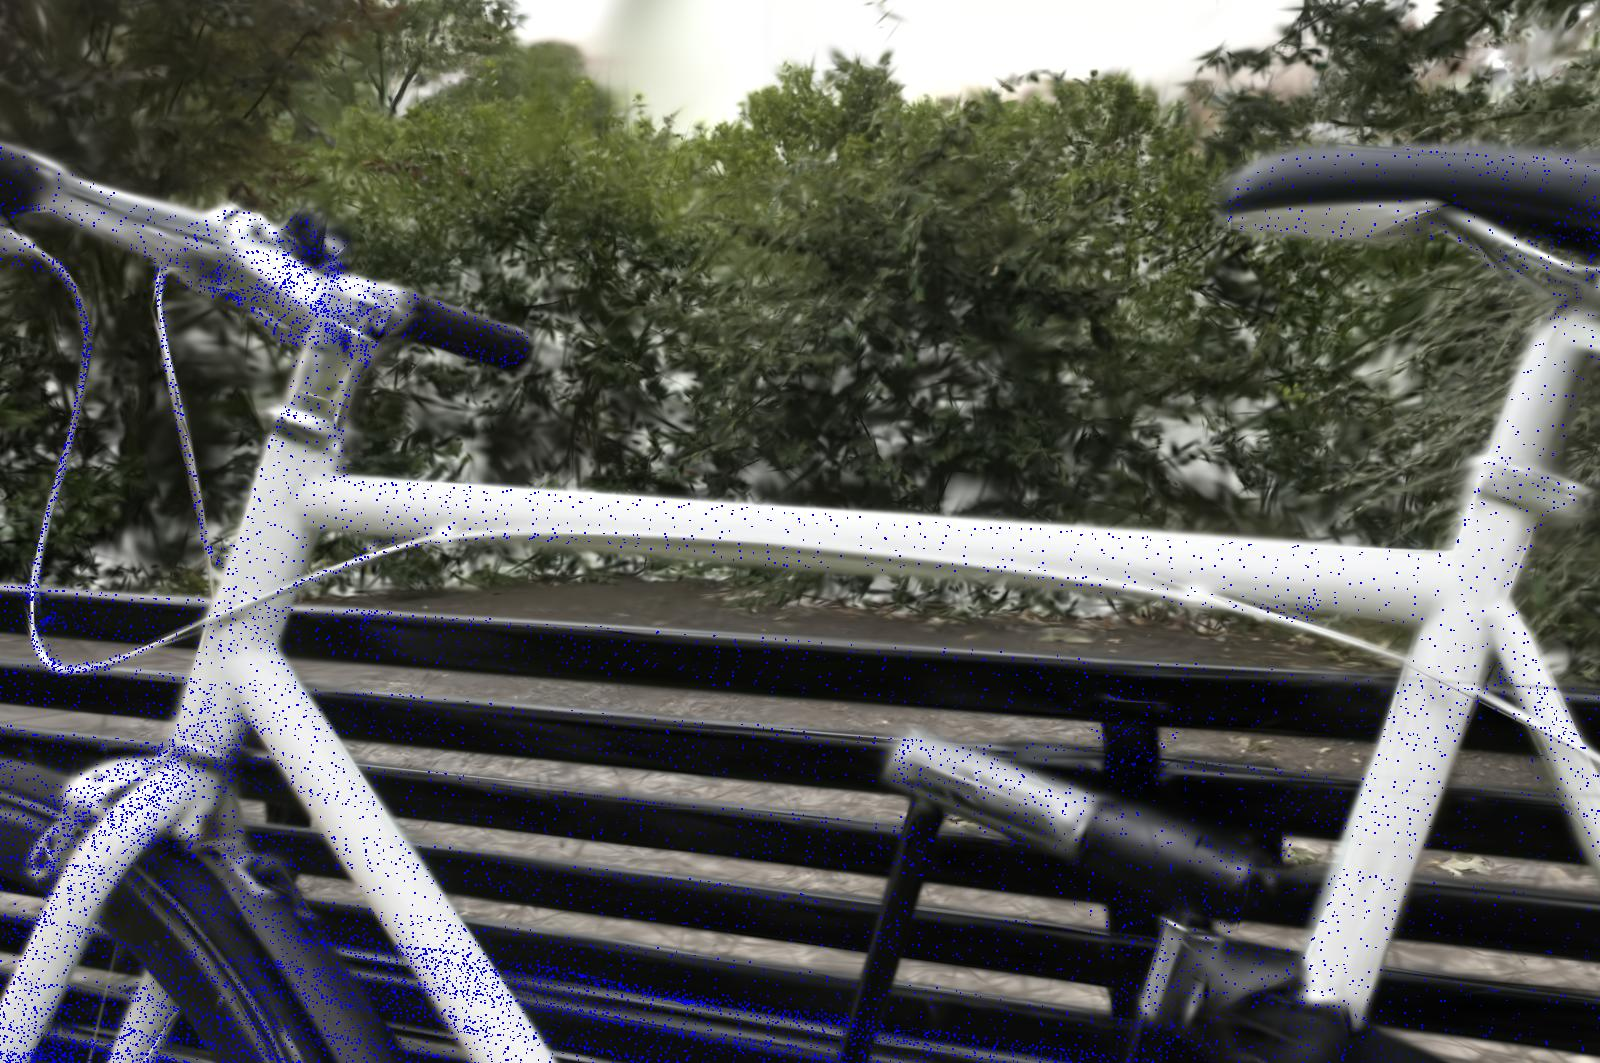

In [21]:
import os, glob

scene_name = os.path.basename(SCENE_PATH.rstrip('/'))
GS_CKPT = os.path.join(OUTPUT_SYMLINK, 'vanilla_gs', scene_name)

# ── Option A: visualize vanilla 3DGS gaussians (no extra arg needed) ───────────
PLY_PATH = ''

# ── Option B: visualize SuGaR refined gaussians ─────────────────────────────
# Automatically finds the exported .ply from the refined_ply output folder.
# Comment out the block below to use Option A (vanilla 3DGS) instead.
refined_ply_dir = os.path.join(OUTPUT_SYMLINK, 'refined_ply', scene_name)
if os.path.isdir(refined_ply_dir):
    plys = glob.glob(os.path.join(refined_ply_dir, '*.ply'))
    if plys:
        PLY_PATH = plys[0]
        print(f"Using SuGaR refined .ply: {PLY_PATH}")
    else:
        print("No .ply found in refined_ply dir — falling back to vanilla 3DGS checkpoint.")
else:
    print("refined_ply dir not found yet — using vanilla 3DGS checkpoint.")

ply_arg = f'--ply_path "{PLY_PATH}"' if PLY_PATH else ''

%cd /content/SuGaR
!python teaser.py -m "{GS_CKPT}" -s "{SCENE_PATH}" {ply_arg}

# Display the result inline
from IPython.display import display, Image as IPImage
display(IPImage('/content/SuGaR/output.jpg'))

## 12. Novel View Synthesis Evaluation (PSNR / SSIM / LPIPS)

Evaluates rendering quality on the held-out test views (every 8th image, same split used during training).

Two models are compared:
- **Vanilla 3DGS (7k iters)** — the intermediate checkpoint produced before SuGaR training
- **Refined SuGaR** — the final model with Gaussians bound to the extracted mesh

Results are saved to `SuGaR_output/nvs_results_scan24.json`.

In [ ]:
import os, sys, json, glob
import torch

sys.path.insert(0, '/content/SuGaR')
os.chdir('/content/SuGaR')

from gaussian_splatting.utils.loss_utils import ssim
from gaussian_splatting.utils.image_utils import psnr
from gaussian_splatting.lpipsPyTorch import lpips
from sugar_scene.gs_model import GaussianSplattingWrapper
from sugar_scene.sugar_model import SuGaR
from sugar_utils.spherical_harmonics import SH2RGB
import open3d as o3d

torch.cuda.set_device(GPU_INDEX)
os.makedirs('./lpipsPyTorch/weights/', exist_ok=True)
torch.hub.set_dir('./lpipsPyTorch/weights/')

GS_CKPT       = os.path.join(OUTPUT_SYMLINK, 'vanilla_gs', SCENE_NAME)
EVAL_INTERVAL = 8   # llffhold — must match the value used during training

# ── Load vanilla 3DGS checkpoint ───────────────────────────────────────────────
print("Loading vanilla 3DGS checkpoint (7k) …")
nerfmodel = GaussianSplattingWrapper(
    source_path=SCENE_PATH,
    output_path=GS_CKPT,
    iteration_to_load=7000,
    load_gt_images=True,
    eval_split=True,
    eval_split_interval=EVAL_INTERVAL,
)
n_test = len(nerfmodel.test_cameras)
print(f"  {n_test} test cameras")

results = {}

# ── 1. Vanilla 3DGS (7k) ──────────────────────────────────────────────────────
print("\nEvaluating vanilla 3DGS (7k) …")
gs_ssims, gs_psnrs, gs_lpipss = [], [], []
with torch.no_grad():
    for idx in range(n_test):
        gt  = nerfmodel.get_test_gt_image(idx).permute(2, 0, 1).unsqueeze(0)
        img = (nerfmodel
               .render_image(nerf_cameras=nerfmodel.test_cameras, camera_indices=idx)
               .clamp(0, 1).permute(2, 0, 1).unsqueeze(0))
        gs_ssims.append(ssim(img, gt).item())
        gs_psnrs.append(psnr(img, gt).item())
        gs_lpipss.append(lpips(img, gt, net_type='vgg').item())

results['3dgs_7k'] = dict(
    psnr=float(torch.tensor(gs_psnrs).mean()),
    ssim=float(torch.tensor(gs_ssims).mean()),
    lpips=float(torch.tensor(gs_lpipss).mean()),
)
print(f"  PSNR  {results['3dgs_7k']['psnr']:.3f}")
print(f"  SSIM  {results['3dgs_7k']['ssim']:.4f}")
print(f"  LPIPS {results['3dgs_7k']['lpips']:.4f}")

# ── 2. Refined SuGaR ──────────────────────────────────────────────────────────
print("\nLoading refined SuGaR model …")
coarse_mesh_dir   = os.path.join(OUTPUT_SYMLINK, 'coarse_mesh', SCENE_NAME)
refined_dir       = os.path.join(OUTPUT_SYMLINK, 'refined', SCENE_NAME)
coarse_mesh_files = sorted(glob.glob(os.path.join(coarse_mesh_dir, '*.ply')))
assert coarse_mesh_files, f"No coarse mesh found in {coarse_mesh_dir}"

refine_iters = {'short': 2000, 'medium': 7000, 'long': 15000}[REFINEMENT_TIME]
refined_subdirs = sorted(glob.glob(os.path.join(refined_dir, '*/')))
assert refined_subdirs, f"No refined model found in {refined_dir}"
refined_ckpt = os.path.join(refined_subdirs[0], f'{refine_iters}.pt')
assert os.path.isfile(refined_ckpt), f"Checkpoint not found: {refined_ckpt}"
print(f"  Coarse mesh:  {os.path.basename(coarse_mesh_files[0])}")
print(f"  Refined ckpt: {refined_ckpt}")

o3d_mesh   = o3d.io.read_triangle_mesh(coarse_mesh_files[0])
checkpoint = torch.load(refined_ckpt, map_location=nerfmodel.device, weights_only=False)
n_gaussians_per_tri = 1 if MESH_QUALITY == 'high_poly' else 6

refined_sugar = SuGaR(
    nerfmodel=nerfmodel,
    points=checkpoint['state_dict']['_points'],
    colors=SH2RGB(checkpoint['state_dict']['_sh_coordinates_dc'][:, 0, :]),
    initialize=False,
    sh_levels=nerfmodel.gaussians.active_sh_degree + 1,
    keep_track_of_knn=False,
    knn_to_track=0,
    beta_mode='average',
    surface_mesh_to_bind=o3d_mesh,
    n_gaussians_per_surface_triangle=n_gaussians_per_tri,
)
refined_sugar.load_state_dict(checkpoint['state_dict'])
refined_sugar.eval()

print("Evaluating refined SuGaR …")
sugar_ssims, sugar_psnrs, sugar_lpipss = [], [], []
with torch.no_grad():
    for idx in range(n_test):
        gt  = nerfmodel.get_test_gt_image(idx).permute(2, 0, 1).unsqueeze(0)
        img = (refined_sugar
               .render_image_gaussian_rasterizer(
                   nerf_cameras=nerfmodel.test_cameras,
                   camera_indices=idx,
                   verbose=False,
                   bg_color=None,
                   sh_deg=nerfmodel.gaussians.active_sh_degree,
                   compute_color_in_rasterizer=True,
               ).clamp(0, 1).permute(2, 0, 1).unsqueeze(0))
        sugar_ssims.append(ssim(img, gt).item())
        sugar_psnrs.append(psnr(img, gt).item())
        sugar_lpipss.append(lpips(img, gt, net_type='vgg').item())

results['sugar_refined'] = dict(
    psnr=float(torch.tensor(sugar_psnrs).mean()),
    ssim=float(torch.tensor(sugar_ssims).mean()),
    lpips=float(torch.tensor(sugar_lpipss).mean()),
)
print(f"  PSNR  {results['sugar_refined']['psnr']:.3f}")
print(f"  SSIM  {results['sugar_refined']['ssim']:.4f}")
print(f"  LPIPS {results['sugar_refined']['lpips']:.4f}")

# ── Save results ───────────────────────────────────────────────────────────────
nvs_result_path = os.path.join(OUTPUT_DIR_DRIVE, f'nvs_results_{SCENE_NAME}.json')
with open(nvs_result_path, 'w') as f:
    json.dump({SCENE_NAME: results}, f, indent=4)
print(f"\nNVS results saved → {nvs_result_path}")

## 13. Geometry Evaluation (Chamfer Distance)

Evaluates the quality of SuGaR's reconstructed geometry against the official DTU GT point clouds.

**What this does:**
1. Loads SuGaR's coarse Poisson mesh from `coarse_mesh/<scene>/`
2. Culls background vertices by projecting through each camera mask (same method as 2DGS)
3. De-normalises the mesh back to DTU world coordinates
4. Samples a dense point cloud from the mesh surface
5. Computes bi-directional Chamfer distance vs the official STL point cloud

**Output:** `d2s` (data→GT), `s2d` (GT→data), `overall` = mean — lower is better.

Results are saved to `SuGaR_output/chamfer_results_scan24.json`.

> **Requires:** DTU GT data at `DTU_GT_PATH` (configured in cell 2) with:
> `ObsMask/ObsMask24_10.mat`, `ObsMask/Plane24.mat`, `Points/stl/stl024_total.ply`

In [ ]:
# Extra dependencies for Chamfer evaluation
# (trimesh + scikit-image are often already present in Colab, but install to be safe)
!pip install -q trimesh scikit-image scipy scikit-learn

In [ ]:
import os, sys, json, glob
import numpy as np
import cv2
import torch
import torch.nn.functional as F
import trimesh
from skimage.morphology import binary_dilation, disk
from tqdm import tqdm
import multiprocessing as mp
from scipy.io import loadmat
import sklearn.neighbors as skln

sys.path.insert(0, '/content/SuGaR')
os.chdir('/content/SuGaR')

# ── Paths ──────────────────────────────────────────────────────────────────────
coarse_mesh_dir   = os.path.join(OUTPUT_SYMLINK, 'coarse_mesh', SCENE_NAME)
coarse_mesh_files = sorted(glob.glob(os.path.join(coarse_mesh_dir, '*.ply')))
assert coarse_mesh_files, f"No coarse mesh PLY found in {coarse_mesh_dir}"
MESH_PATH = coarse_mesh_files[0]
print(f"Evaluating mesh: {os.path.basename(MESH_PATH)}")

CHAMFER_OUT = os.path.join(OUTPUT_DIR_DRIVE, f'chamfer_{SCENE_NAME}')
os.makedirs(CHAMFER_OUT, exist_ok=True)

# ── Load cameras and masks from cameras.npz (NeuS format) ─────────────────────
# These are the same cameras used for culling in the 2DGS DTU eval pipeline.
camera_dict = np.load(os.path.join(SCENE_PATH, 'cameras.npz'))
image_paths = sorted(glob.glob(os.path.join(SCENE_PATH, 'images', '*.png')))
n_images    = len(image_paths)

intrinsics_all, pose_all, scale_mats = [], [], []
for i in range(n_images):
    world_mat = camera_dict[f'world_mat_{i}'].astype(np.float32)
    scale_mat  = camera_dict[f'scale_mat_{i}'].astype(np.float32)
    P          = (world_mat @ scale_mat)[:3, :4]
    out        = cv2.decomposeProjectionMatrix(P)
    K          = out[0]; K /= K[2, 2]
    R          = out[1]
    t_h        = out[2]
    cam_center = (t_h[:3] / t_h[3]).reshape(3)
    intrinsics = np.eye(4, dtype=np.float32); intrinsics[:3, :3] = K
    pose       = np.eye(4, dtype=np.float32)
    pose[:3, :3] = R.T; pose[:3, 3] = cam_center
    intrinsics_all.append(torch.from_numpy(intrinsics).float())
    pose_all.append(torch.from_numpy(pose).float())
    scale_mats.append(scale_mat)

mask_paths = sorted(glob.glob(os.path.join(SCENE_PATH, 'mask', '*.png')))
masks = [cv2.imread(p) for p in mask_paths]
W, H = 1600, 1200   # DTU image dimensions (hard-coded per dataset spec)

# ── Mesh culling ───────────────────────────────────────────────────────────────
print("Culling mesh with camera masks …")
mesh  = trimesh.load(MESH_PATH)
verts = torch.from_numpy(np.asarray(mesh.vertices)).float().cuda()
verts = torch.cat([verts, torch.ones_like(verts[:, :1])], dim=-1).T   # 4×N

sampled_masks = []
for i in tqdm(range(n_images), desc='Projecting cameras'):
    w2c       = torch.inverse(pose_all[i]).cuda()
    intrinsic = intrinsics_all[i].cuda()
    with torch.no_grad():
        cam_pts = intrinsic @ w2c @ verts
        pix     = cam_pts[:2] / (cam_pts[2].unsqueeze(0) + 1e-6)
        pix     = pix.T
        pix[..., 0] /= W - 1
        pix[..., 1] /= H - 1
        pix = (pix - 0.5) * 2
        valid = ((pix > -1.) & (pix < 1.)).all(dim=-1).float()

        maski = masks[i][:, :, 0].astype(np.float32) / 256.
        maski = torch.from_numpy(binary_dilation(maski, disk(24))).float()[None, None].cuda()
        smask = F.grid_sample(maski, pix[None, None], mode='nearest',
                              padding_mode='zeros', align_corners=True)[0, -1, 0]
        smask = smask + (1. - valid)
        sampled_masks.append(smask)

sampled_masks = torch.stack(sampled_masks, dim=-1)
vert_mask = (sampled_masks > 0.).all(dim=-1).cpu().numpy()
face_mask = vert_mask[mesh.faces].all(axis=1)
mesh.update_vertices(vert_mask)
mesh.update_faces(face_mask)

# De-normalise: transform from the training (scale_mat-normalised) coordinate space
# back to the original DTU world space so it aligns with the GT point clouds.
sm = scale_mats[0]
mesh.vertices = mesh.vertices * sm[0, 0] + sm[:3, 3][None]

culled_path = os.path.join(CHAMFER_OUT, 'culled_mesh.ply')
mesh.export(culled_path)
print(f"Culled mesh → {culled_path}  ({len(mesh.vertices)} vertices)")
del mesh

# ── Sample dense point cloud from mesh surface ─────────────────────────────────
print("\nComputing Chamfer distance …")
data_mesh = trimesh.load(culled_path)
vertices  = np.asarray(data_mesh.vertices)
triangles = np.asarray(data_mesh.triangles)
tri_vert  = vertices[triangles]

v1 = tri_vert[:, 1] - tri_vert[:, 0]
v2 = tri_vert[:, 2] - tri_vert[:, 0]
l1 = np.linalg.norm(v1, axis=-1, keepdims=True)
l2 = np.linalg.norm(v2, axis=-1, keepdims=True)
area2 = np.linalg.norm(np.cross(v1, v2), axis=-1, keepdims=True)
nz = (area2 > 0)[:, 0]
l1, l2, area2, v1, v2, tri_vert = [a[nz] for a in [l1, l2, area2, v1, v2, tri_vert]]

DOWNSAMPLE_DENSITY = 0.2
thr    = DOWNSAMPLE_DENSITY * np.sqrt(l1 * l2 / area2)
n1_arr = np.floor(l1 / thr)
n2_arr = np.floor(l2 / thr)

def _sample_tri(args):
    n1, n2, v1_, v2_, tv = args
    c = np.mgrid[:n1 + 1, :n2 + 1].astype(float) + 0.5
    c[0] /= max(n1, 1e-7)
    c[1] /= max(n2, 1e-7)
    c = c.transpose(1, 2, 0)
    k = c[c.sum(-1) < 1]
    return v1_ * k[:, :1] + v2_ * k[:, 1:] + tv

with mp.Pool() as pool:
    new_pts = pool.map(
        _sample_tri,
        [(n1_arr[i, 0], n2_arr[i, 0], v1[i:i+1], v2[i:i+1], tri_vert[i:i+1, 0])
         for i in range(len(n1_arr))],
        chunksize=1024)

data_pcd = np.concatenate([vertices] + new_pts, axis=0)

# Voxel-based downsampling (matches 2DGS eval script)
rng = np.random.default_rng()
rng.shuffle(data_pcd, axis=0)
nn = skln.NearestNeighbors(n_neighbors=1, radius=DOWNSAMPLE_DENSITY,
                            algorithm='kd_tree', n_jobs=-1)
nn.fit(data_pcd)
rnn_idxs = nn.radius_neighbors(data_pcd, radius=DOWNSAMPLE_DENSITY, return_distance=False)
keep = np.ones(len(data_pcd), dtype=bool)
for curr, idxs in enumerate(rnn_idxs):
    if keep[curr]:
        keep[idxs] = 0
        keep[curr] = 1
data_down = data_pcd[keep]

# ── Apply ObsMask (restrict to observed region) ────────────────────────────────
import open3d as _o3d
obs_file = loadmat(os.path.join(DTU_GT_PATH, 'ObsMask', f'ObsMask{DTU_SCAN_ID}_10.mat'))
ObsMask, BB, Res = [obs_file[k] for k in ['ObsMask', 'BB', 'Res']]
BB = BB.astype(np.float32)

PATCH = 60.0
inbound   = ((data_down >= BB[:1] - PATCH) & (data_down < BB[1:] + PATCH * 2)).sum(-1) == 3
data_in   = data_down[inbound]
data_grid = np.around((data_in - BB[:1]) / Res).astype(np.int32)
grid_ok   = ((data_grid >= 0) & (data_grid < np.expand_dims(ObsMask.shape, 0))).sum(-1) == 3
data_grid_in = data_grid[grid_ok]
in_obs       = ObsMask[data_grid_in[:, 0], data_grid_in[:, 1], data_grid_in[:, 2]].astype(bool)
data_in_obs  = data_in[grid_ok][in_obs]

# ── Load GT STL point cloud ────────────────────────────────────────────────────
stl_path = os.path.join(DTU_GT_PATH, 'Points', 'stl', f'stl{DTU_SCAN_ID:03d}_total.ply')
stl_pcd  = _o3d.io.read_point_cloud(stl_path)
stl      = np.asarray(stl_pcd.points)

MAX_DIST = 20.0

# data → GT distance
nn.fit(stl)
dist_d2s, _ = nn.kneighbors(data_in_obs, n_neighbors=1, return_distance=True)
mean_d2s    = dist_d2s[dist_d2s < MAX_DIST].mean()

# GT → data distance (filtered above ground plane)
ground_plane = loadmat(
    os.path.join(DTU_GT_PATH, 'ObsMask', f'Plane{DTU_SCAN_ID}.mat'))['P']
stl_hom  = np.concatenate([stl, np.ones_like(stl[:, :1])], axis=-1)
above    = (ground_plane.reshape(1, 4) * stl_hom).sum(-1) > 0
stl_above = stl[above]

nn.fit(data_in)
dist_s2d, _ = nn.kneighbors(stl_above, n_neighbors=1, return_distance=True)
mean_s2d    = dist_s2d[dist_s2d < MAX_DIST].mean()

chamfer_overall = (mean_d2s + mean_s2d) / 2

print(f"\nChamfer Results ({SCENE_NAME}):")
print(f"  d2s (data→GT):  {mean_d2s:.4f}")
print(f"  s2d (GT→data):  {mean_s2d:.4f}")
print(f"  Overall:        {chamfer_overall:.4f}")

chamfer_result_path = os.path.join(OUTPUT_DIR_DRIVE, f'chamfer_results_{SCENE_NAME}.json')
with open(chamfer_result_path, 'w') as f:
    json.dump({
        SCENE_NAME: {
            'd2s': float(mean_d2s),
            's2d': float(mean_s2d),
            'overall': float(chamfer_overall),
        }
    }, f, indent=4)
print(f"Chamfer results saved → {chamfer_result_path}")